In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../../../../Data/ushape.csv")
df

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0
...,...,...,...
94,1.699453,0.587720,1.0
95,0.218623,-0.652521,1.0
96,0.952914,-0.419766,1.0
97,-1.318500,0.423112,0.0


In [3]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

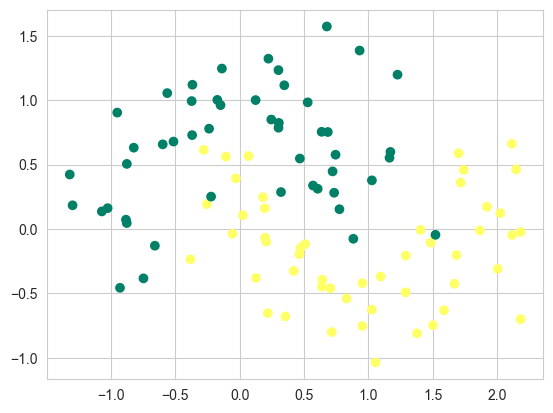

In [4]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df.iloc[:,2],cmap='summer')

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Using Linear Decision Line 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.95

In [8]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(lr, X, y, scoring='accuracy', cv=10))

np.float64(0.8300000000000001)

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

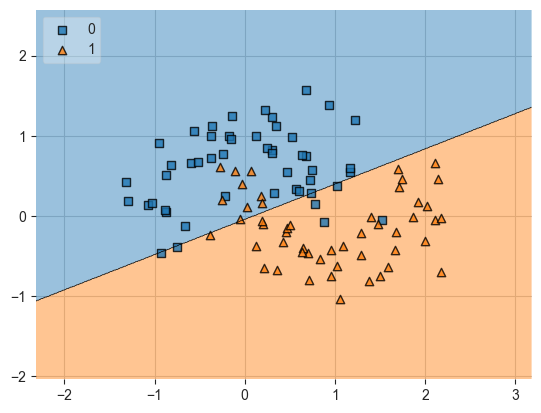

In [7]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values.astype("int"), lr, legend=2)

# Using Linear Decision Line 

In [11]:
from sklearn.preprocessing import PolynomialFeatures

lr = LogisticRegression()
poly = PolynomialFeatures(degree=3, include_bias=False)

X_train_trf = poly.fit_transform(X_train)
X_test_trf = poly.transform(X_test)

lr.fit(X_train_trf, y_train)
y_pred = lr.predict(X_test_trf)
accuracy_score(y_test, y_pred)

1.0

In [12]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_trf = poly.fit_transform(X)

np.mean(cross_val_score(lr, X_trf, y, scoring='accuracy', cv=10))

np.float64(0.9099999999999999)

In [27]:
from sklearn.pipeline import Pipeline

def nonLinearDecisionBoundary(X, y, degree=1):
    pipe = Pipeline([
        ("poly",PolynomialFeatures(degree=degree, include_bias=False)),
        ("lr",LogisticRegression())
    ])    
    
    pipe.fit(X, y)
    
    score = np.mean(cross_val_score(pipe, X, y, scoring='accuracy', cv=10))
    
    x_range = np.arange(X.iloc[:,0].min()-1, X.iloc[:,0].max()+1, step=0.01)
    y_range = np.arange(X.iloc[:,1].min()-1, X.iloc[:,1].max()+1, step=0.01)
    
    XX, YY = np.meshgrid(x_range, y_range)
    
    grid = np.c_[XX.ravel(), YY.ravel()]
    
    Z = pipe.predict(grid)
    
    Z = Z.reshape(XX.shape)
    
    plt.contourf(XX, YY, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y, edgecolors='k')
    plt.title(f"Degree: {degree}, Accuracy:{np.round(score, 2)}")
    plt.show()

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


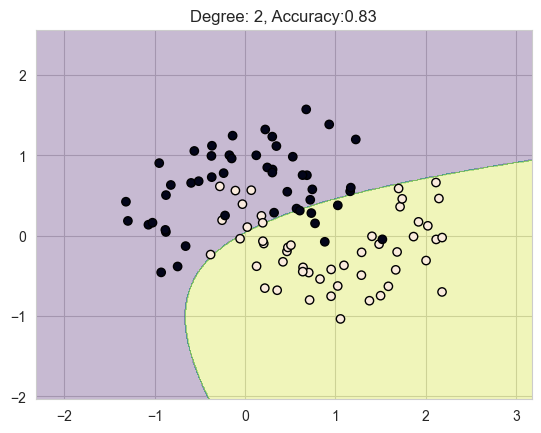

In [28]:
nonLinearDecisionBoundary(X, y, degree=2)

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


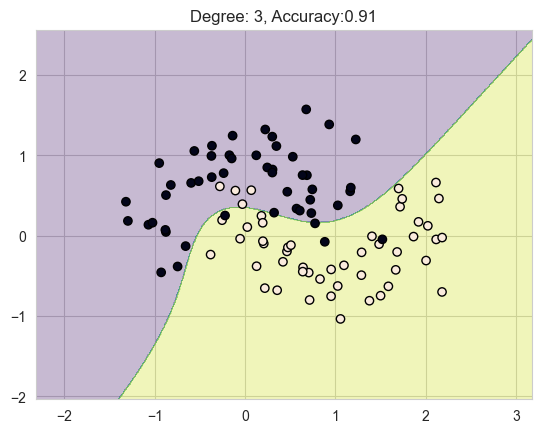

In [29]:
nonLinearDecisionBoundary(X, y, degree=3)

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


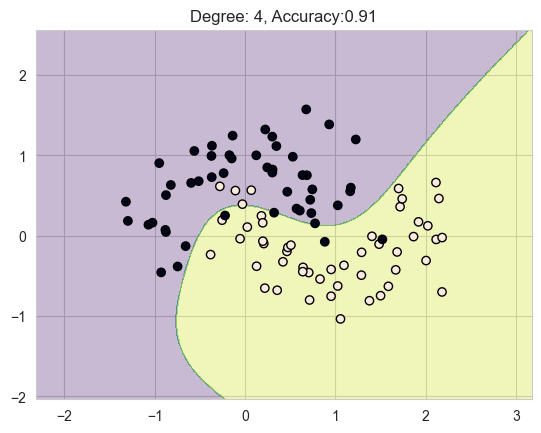

In [30]:
nonLinearDecisionBoundary(X, y, degree=4)